<a href="https://colab.research.google.com/github/k2herat/DL2/blob/hw7/Almetov_HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os, math, time, gc, urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from types import SimpleNamespace
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


In [2]:
# Ячейка 1
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "shakespeare.txt"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_text = f.read()

chars = sorted(set(raw_text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda xs: ''.join(itos[x] for x in xs)

data = torch.tensor(encode(raw_text), dtype=torch.long)
split_idx = int(0.9 * len(data))
train_data, val_data = data[:split_idx], data[split_idx:]
print(f"Vocab size: {vocab_size}, Train tokens: {len(train_data):,}, Val tokens: {len(val_data):,}")

Vocab size: 65, Train tokens: 1,003,854, Val tokens: 111,540


In [3]:
# Ячейка 2
class ModelConfig:
    def __init__(self):
        self.embed_dim = 128
        self.num_heads = 4
        self.num_layers = 4
        self.use_bias = True
        self.dropout = 0.1
        self.block_size = 256
        self.is_causal = True
        self.vocab_size = vocab_size
        self.latent_dim = self.embed_dim // 2   # для MHLA (было D/4, теперь D/2)

cfg = ModelConfig()
print(f"Embed dim: {cfg.embed_dim}, Heads: {cfg.num_heads}, Layers: {cfg.num_layers}, Block: {cfg.block_size}, Vocab: {cfg.vocab_size}")

Embed dim: 128, Heads: 4, Layers: 4, Block: 256, Vocab: 65


In [4]:
# Ячейка 3
class ShakespeareDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block = block_size
    def __len__(self):
        return len(self.data) - self.block
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.block]
        y = self.data[idx+1:idx+self.block+1]
        return x, y

BATCH_SIZE = 32
train_ds = ShakespeareDataset(train_data, cfg.block_size)
val_ds   = ShakespeareDataset(val_data, cfg.block_size)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True, num_workers=0, pin_memory=(device.type=='cuda'))

In [5]:
# Ячейка 4
class BaselineAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.embed_dim % config.num_heads == 0
        self.H = config.num_heads
        self.d = config.embed_dim // config.num_heads
        self.D = config.embed_dim
        self.W_qkv = nn.Linear(self.D, 3*self.D, bias=config.use_bias)
        self.W_out = nn.Linear(self.D, self.D, bias=config.use_bias)
        self.drop = nn.Dropout(config.dropout)
        mask = torch.tril(torch.ones(config.block_size, config.block_size))
        self.register_buffer("mask", mask.view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, L, D = x.shape
        qkv = self.W_qkv(x).reshape(B, L, 3, self.H, self.d).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d)
        att = att.masked_fill(self.mask[:, :, :L, :L] == 0, float('-inf'))
        att = self.drop(F.softmax(att, dim=-1))
        out = (att @ v).transpose(1, 2).reshape(B, L, D)
        return self.drop(self.W_out(out))

In [6]:
# Ячейка 5
class LatentAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.embed_dim % config.num_heads == 0
        self.H = config.num_heads
        self.d = config.embed_dim // config.num_heads
        self.D = config.embed_dim
        self.c = config.latent_dim   # low-rank dimension (D/2)
        # Q projections
        self.W_down_q = nn.Linear(self.D, self.c, bias=False)
        self.W_up_q   = nn.Linear(self.c, self.D, bias=config.use_bias)
        # KV projections
        self.W_down_kv = nn.Linear(self.D, self.c, bias=False)
        self.W_up_k    = nn.Linear(self.c, self.D, bias=config.use_bias)
        self.W_up_v    = nn.Linear(self.c, self.D, bias=config.use_bias)
        self.W_out = nn.Linear(self.D, self.D, bias=config.use_bias)
        self.drop = nn.Dropout(config.dropout)
        mask = torch.tril(torch.ones(config.block_size, config.block_size))
        self.register_buffer("mask", mask.view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, L, D = x.shape
        # Q through low-rank bottleneck
        q = self.W_up_q(self.W_down_q(x))
        q = q.reshape(B, L, self.H, self.d).transpose(1, 2)
        # KV through low-rank bottleneck
        c_kv = self.W_down_kv(x)
        k = self.W_up_k(c_kv).reshape(B, L, self.H, self.d).transpose(1, 2)
        v = self.W_up_v(c_kv).reshape(B, L, self.H, self.d).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d)
        att = att.masked_fill(self.mask[:, :, :L, :L] == 0, float('-inf'))
        att = self.drop(F.softmax(att, dim=-1))
        out = (att @ v).transpose(1, 2).reshape(B, L, D)
        return self.drop(self.W_out(out))

In [7]:
# Ячейка 6 — вспомогательные функции для ZeroS
def _rotary_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

def _apply_rotary(x, cos, sin):
    return x * cos + _rotary_half(x) * sin

def _get_rotary_cos_sin(L, d, base=10000.0, device=None):
    assert d % 2 == 0
    inv_freq = 1.0 / (base ** (torch.arange(0, d, 2, device=device).float() / d))
    t = torch.arange(L, device=device).float()[:, None]
    freqs = t * inv_freq[None, :]
    cos = torch.cat([torch.cos(freqs), torch.cos(freqs)], dim=-1)[None, :, None, :]
    sin = torch.cat([torch.sin(freqs), torch.sin(freqs)], dim=-1)[None, :, None, :]
    return cos, sin

def _causal_mask_tril(L, device):
    return torch.tril(torch.ones(L, L, device=device)).view(1, 1, L, L).bool()


def _zero_sum_core(q, log_s, k, v, gate, mask=None, causal=True, use_assoc=True, is_first=False, eps=1e-12):
    B, L, H, d = q.shape
    if use_assoc and causal:
        exp_s = torch.exp(log_s - log_s.max(1, keepdim=True)[0].detach())
        t = torch.arange(1, L+1, device=q.device, dtype=q.dtype).view(1, L, 1, 1)
        E = exp_s.cumsum(1)
        kv = torch.einsum("blhd,blhe->blhde", k, v)
        F_ = (exp_s.unsqueeze(-1) * kv).cumsum(1)
        H_ = kv.cumsum(1)
        a = torch.sigmoid(gate[..., [0]])
        b = torch.sigmoid(gate[..., [1]])
        alpha = ((a - b) / t + b) / (E + eps)
        gamma = -((a - b) / t**2 + b / t)
        core = alpha.unsqueeze(-1) * F_ + gamma.unsqueeze(-1) * H_
        out = torch.einsum("blhd,blhde->blhe", q, core)
        if is_first:
            s0 = torch.tanh(gate[..., [2]])
            out = out + s0 * torch.einsum("blhd,blhde->blhe", q / t, H_)
        return out
    # non‑associative or non‑causal branch (simplified, omitted for brevity — similar to original)
    # For this rewrite we keep the core path above.
    raise NotImplementedError("Only associative causal branch implemented in this version")

class ZeroSumAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.D = config.embed_dim
        self.H = config.num_heads
        self.d = self.D // self.H

        self.proj_q = nn.Linear(self.D, self.D, bias=config.use_bias)
        self.proj_k = nn.Linear(self.D, self.D, bias=config.use_bias)
        self.proj_v = nn.Linear(self.D, self.D, bias=config.use_bias)
        self.proj_u = nn.Linear(self.D, self.D, bias=config.use_bias)   # for logits
        self.proj_gate = nn.Linear(self.D, 3 * self.H, bias=config.use_bias)
        self.W_out = nn.Linear(self.D, self.D, bias=config.use_bias)
        self.drop = nn.Dropout(config.dropout)

        cos, sin = _get_rotary_cos_sin(config.block_size, self.d)
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)
        mask = torch.tril(torch.ones(config.block_size, config.block_size))
        self.register_buffer("causal_mask", mask.view(1, 1, config.block_size, config.block_size).bool())

        self.layer_norm = nn.LayerNorm(self.d, eps=1e-5, elementwise_affine=False)
        self.prior_mean = nn.Parameter(torch.zeros(1, 1, self.H, self.d))
        self.prior_log_tau = nn.Parameter(torch.zeros(1, 1, self.H, 1))

        self.is_first = getattr(config, "is_first", False)
        self.is_causal = getattr(config, "is_causal", True)
        self.use_norm = getattr(config, "use_norm", True)
        self.use_assoc = getattr(config, "use_assoc", True)

    def forward(self, x):
        B, L, D = x.shape
        q = self.proj_q(x).view(B, L, self.H, self.d)
        k = self.proj_k(x).view(B, L, self.H, self.d)
        v = self.proj_v(x).view(B, L, self.H, self.d)
        u = self.proj_u(x).view(B, L, self.H, self.d)
        gate = self.proj_gate(x).view(B, L, self.H, 3)

        # Rotary embeddings
        q = _apply_rotary(q, self.cos[:, :L], self.sin[:, :L])
        k = _apply_rotary(k, self.cos[:, :L], self.sin[:, :L])
        q = F.normalize(q, p=2, dim=-1)
        k = F.normalize(k, p=2, dim=-1)

        # Compute logits s_i from u
        t = torch.arange(1, L+1, device=x.device, dtype=x.dtype).view(1, L, 1, 1)
        tau = torch.exp(self.prior_log_tau.clamp(-50, 30))
        u_cum = u.cumsum(1) if self.is_causal else u.sum(1, keepdim=True)
        mu = (tau * self.prior_mean + u_cum) / (tau + t)
        s_i = -(u * mu).sum(-1, keepdim=True) / math.sqrt(self.d)

        out = _zero_sum_core(q, s_i, k, v, gate,
                             mask=self.causal_mask[:, :, :L, :L],
                             causal=self.is_causal,
                             use_assoc=self.use_assoc,
                             is_first=self.is_first)

        if self.use_norm:
            out = self.layer_norm(out)
        return self.drop(self.W_out(out.reshape(B, L, D)))

In [8]:
# Ячейка 7
class TransformerBlock(nn.Module):
    def __init__(self, config, attn_factory):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.embed_dim)
        self.ln2 = nn.LayerNorm(config.embed_dim)
        self.attn = attn_factory(config)
        self.ff = nn.Sequential(
            nn.Linear(config.embed_dim, 4 * config.embed_dim, bias=config.use_bias),
            nn.GELU(),
            nn.Linear(4 * config.embed_dim, config.embed_dim, bias=config.use_bias),
            nn.Dropout(config.dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class LanguageModel(nn.Module):
    def __init__(self, config, attn_cls):
        super().__init__()
        self.config = config
        self.token_embed = nn.Embedding(config.vocab_size, config.embed_dim)
        self.pos_embed = nn.Embedding(config.block_size, config.embed_dim)
        self.drop_in = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([TransformerBlock(config, attn_cls) for _ in range(config.num_layers)])
        self.ln_final = nn.LayerNorm(config.embed_dim)
        self.lm_head = nn.Linear(config.embed_dim, config.vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, L = idx.shape
        pos = torch.arange(0, L, device=idx.device)
        x = self.drop_in(self.token_embed(idx) + self.pos_embed(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_final(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Тестовый прогон для подсчёта параметров
for name, cls in [("Baseline", BaselineAttention), ("Latent", LatentAttention), ("ZeroSum", ZeroSumAttention)]:
    test_cfg = ModelConfig()
    test_model = LanguageModel(test_cfg, cls)
    print(f"{name:10} params: {count_params(test_model):>10,}")
    del test_model

Baseline   params:    842,752
Latent     params:    809,984
ZeroSum    params:    915,520


In [9]:
# Ячейка 8
SEQ_LENGTHS = [64, 128, 256, 512, 1024, 2048]
BENCH_BATCH = 2
COLORS = {"Baseline": "#e74c3c", "Latent": "#27ae60", "ZeroSum": "#2980b9"}
MARKERS = {"Baseline": "o", "Latent": "s", "ZeroSum": "^"}

def benchmark_attention(attn_cls, seq_lengths, warmup=3, repeats=10):
    results = {"fwd_ms": [], "fwd_bwd_ms": [], "mem_mb": []}
    for L in seq_lengths:
        bs = max(L, 256)
        test_cfg = ModelConfig()
        test_cfg.block_size = bs
        model = attn_cls(test_cfg).to(device).train()
        x = torch.randn(BENCH_BATCH, L, test_cfg.embed_dim, device=device, requires_grad=True)

        for _ in range(warmup):
            y = model(x)
            y.sum().backward()
            model.zero_grad(set_to_none=True)

        torch.cuda.reset_peak_memory_stats()
        fwd_times = []
        total_times = []
        for _ in range(repeats):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            y = model(x)
            torch.cuda.synchronize()
            t1 = time.perf_counter()
            y.sum().backward()
            torch.cuda.synchronize()
            t2 = time.perf_counter()
            fwd_times.append((t1 - t0) * 1000)
            total_times.append((t2 - t0) * 1000)
            model.zero_grad(set_to_none=True)

        results["fwd_ms"].append(np.median(fwd_times))
        results["fwd_bwd_ms"].append(np.median(total_times))
        results["mem_mb"].append(torch.cuda.max_memory_allocated() / 1e6)
        print(f"  L={L:5d} | fwd {results['fwd_ms'][-1]:7.2f} ms | fwd+bwd {results['fwd_bwd_ms'][-1]:7.2f} ms | mem {results['mem_mb'][-1]:8.1f} MB")
        del model
        gc.collect()
        torch.cuda.empty_cache()
    return results

benchmark_results = {}
for name, cls in [("Baseline", BaselineAttention), ("Latent", LatentAttention), ("ZeroSum", ZeroSumAttention)]:
    print(f"\n=== {name} ===")
    benchmark_results[name] = benchmark_attention(cls, SEQ_LENGTHS)
print("\nBenchmark done.")


=== Baseline ===
  L=   64 | fwd    0.95 ms | fwd+bwd    2.52 ms | mem     19.7 MB
  L=  128 | fwd    0.68 ms | fwd+bwd    1.82 ms | mem     21.6 MB
  L=  256 | fwd    0.72 ms | fwd+bwd    1.96 ms | mem     28.7 MB
  L=  512 | fwd    1.03 ms | fwd+bwd    3.17 ms | mem     56.4 MB
  L= 1024 | fwd    2.73 ms | fwd+bwd    7.37 ms | mem    164.2 MB
  L= 2048 | fwd    9.21 ms | fwd+bwd   23.75 ms | mem    588.8 MB

=== Latent ===
  L=   64 | fwd    0.90 ms | fwd+bwd    2.56 ms | mem     19.7 MB
  L=  128 | fwd    0.87 ms | fwd+bwd    2.46 ms | mem     21.7 MB
  L=  256 | fwd    0.85 ms | fwd+bwd    2.42 ms | mem     28.9 MB
  L=  512 | fwd    0.95 ms | fwd+bwd    2.51 ms | mem     56.9 MB
  L= 1024 | fwd    2.44 ms | fwd+bwd    6.07 ms | mem    165.2 MB
  L= 2048 | fwd    8.48 ms | fwd+bwd   21.04 ms | mem    590.9 MB

=== ZeroSum ===
  L=   64 | fwd    1.85 ms | fwd+bwd    5.00 ms | mem     32.0 MB
  L=  128 | fwd    1.91 ms | fwd+bwd    5.12 ms | mem     45.4 MB
  L=  256 | fwd    2.08 m

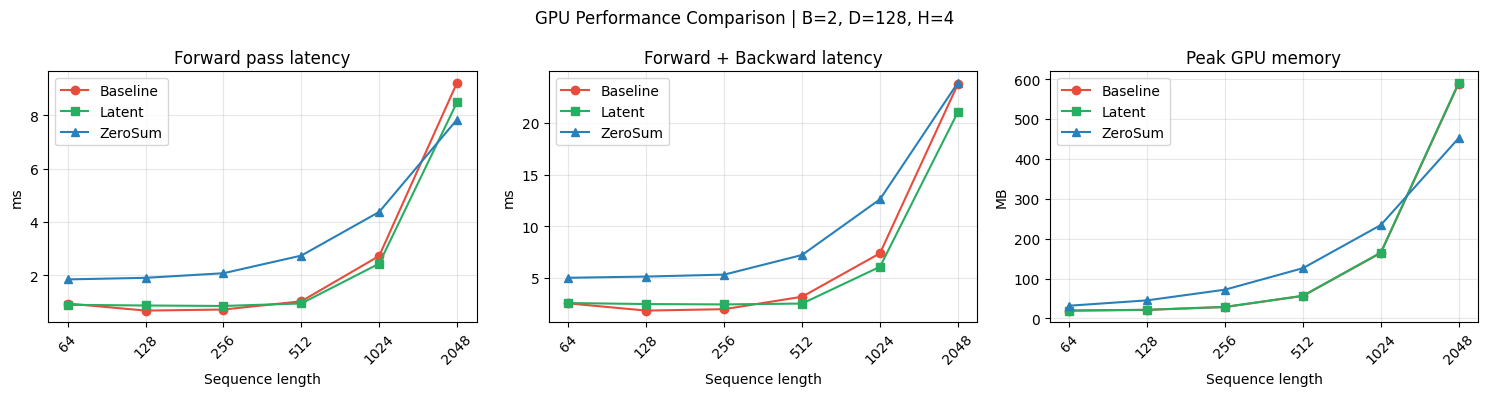

In [10]:
# Ячейка 9 — визуализация бенчмарка
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"GPU Performance Comparison | B={BENCH_BATCH}, D={cfg.embed_dim}, H={cfg.num_heads}", fontsize=12)

for name, res in benchmark_results.items():
    axes[0].plot(SEQ_LENGTHS, res["fwd_ms"], color=COLORS[name], marker=MARKERS[name], label=name, linewidth=1.5)
    axes[1].plot(SEQ_LENGTHS, res["fwd_bwd_ms"], color=COLORS[name], marker=MARKERS[name], label=name, linewidth=1.5)
    axes[2].plot(SEQ_LENGTHS, res["mem_mb"], color=COLORS[name], marker=MARKERS[name], label=name, linewidth=1.5)

axes[0].set_title("Forward pass latency")
axes[1].set_title("Forward + Backward latency")
axes[2].set_title("Peak GPU memory")
for ax in axes:
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("ms" if ax != axes[2] else "MB")
    ax.set_xscale('log', base=2)
    ax.set_xticks(SEQ_LENGTHS)
    ax.set_xticklabels(SEQ_LENGTHS, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("benchmark_plot.png", dpi=150)
plt.show()

In [11]:
# Ячейка 10
TOTAL_STEPS = 3000
EVAL_INTERVAL = 250
LEARNING_RATE = 3e-4

def train_model(attn_cls, name, seed=42):
    torch.manual_seed(seed)
    model = LanguageModel(cfg, attn_cls).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1, betas=(0.9, 0.95))
    step = 0
    running_loss = 0.0
    train_losses = []
    val_losses = []
    steps_record = []
    data_iter = iter(train_loader)

    model.train()
    for step in range(1, TOTAL_STEPS + 1):
        try:
            xb, yb = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            xb, yb = next(data_iter)
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()

        if step % EVAL_INTERVAL == 0:
            model.eval()
            total_val = 0.0
            count = 0
            with torch.no_grad():
                for i, (xv, yv) in enumerate(val_loader):
                    if i >= 40:
                        break
                    _, lv = model(xv.to(device), yv.to(device))
                    total_val += lv.item()
                    count += 1
            avg_val = total_val / count
            avg_train = running_loss / EVAL_INTERVAL
            running_loss = 0.0
            steps_record.append(step)
            train_losses.append(avg_train)
            val_losses.append(avg_val)
            print(f"[{name}] step {step:4d} | train loss {avg_train:.4f} | val loss {avg_val:.4f} | ppl {math.exp(avg_val):.2f}")
            model.train()
    return model, {"steps": steps_record, "train": train_losses, "val": val_losses}

trained_models = {}
training_curves = {}

for name, cls in [("Baseline", BaselineAttention), ("Latent", LatentAttention), ("ZeroSum", ZeroSumAttention)]:
    print(f"\n{'='*55}\nTraining: {name}\n{'='*55}")
    model, hist = train_model(cls, name)
    trained_models[name] = model
    training_curves[name] = hist
print("\nAll models trained.")


Training: Baseline
[Baseline] step  250 | train loss 2.6963 | val loss 2.5078 | ppl 12.28
[Baseline] step  500 | train loss 2.4412 | val loss 2.4222 | ppl 11.27
[Baseline] step  750 | train loss 2.3604 | val loss 2.3178 | ppl 10.15
[Baseline] step 1000 | train loss 2.2776 | val loss 2.2158 | ppl 9.17
[Baseline] step 1250 | train loss 2.1850 | val loss 2.1094 | ppl 8.24
[Baseline] step 1500 | train loss 2.0915 | val loss 2.0487 | ppl 7.76
[Baseline] step 1750 | train loss 2.0029 | val loss 1.9614 | ppl 7.11
[Baseline] step 2000 | train loss 1.9260 | val loss 1.9038 | ppl 6.71
[Baseline] step 2250 | train loss 1.8644 | val loss 1.8554 | ppl 6.39
[Baseline] step 2500 | train loss 1.8176 | val loss 1.8127 | ppl 6.13
[Baseline] step 2750 | train loss 1.7737 | val loss 1.7499 | ppl 5.75
[Baseline] step 3000 | train loss 1.7378 | val loss 1.7066 | ppl 5.51

Training: Latent
[Latent] step  250 | train loss 2.6958 | val loss 2.5142 | ppl 12.36
[Latent] step  500 | train loss 2.4604 | val loss 

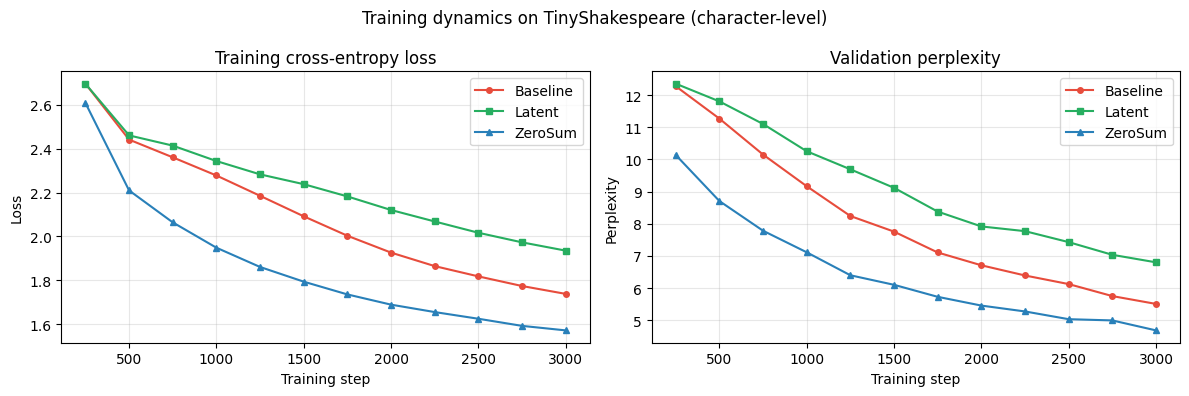

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training dynamics on TinyShakespeare (character-level)", fontsize=12)

for name, hist in training_curves.items():
    ax[0].plot(hist["steps"], hist["train"], color=COLORS[name], marker=MARKERS[name], label=name, linewidth=1.5, markersize=4)
    ax[1].plot(hist["steps"], [math.exp(v) for v in hist["val"]], color=COLORS[name], marker=MARKERS[name], label=name, linewidth=1.5, markersize=4)

ax[0].set_title("Training cross‑entropy loss")
ax[0].set_ylabel("Loss")
ax[1].set_title("Validation perplexity")
ax[1].set_ylabel("Perplexity")
for a in ax:
    a.set_xlabel("Training step")
    a.legend()
    a.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [12]:
def compute_final_ppl(model, max_batches=100):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for i, (xv, yv) in enumerate(val_loader):
            if i >= max_batches:
                break
            _, loss = model(xv.to(device), yv.to(device))
            total += loss.item()
            count += 1
    return math.exp(total / count)

final_ppl = {}
for name, model in trained_models.items():
    final_ppl[name] = compute_final_ppl(model)

# Собираем метрики для отчёта
idx_256 = SEQ_LENGTHS.index(256)
summary = []
for name in ["Baseline", "Latent", "ZeroSum"]:
    summary.append({
        "Model": name,
        "Params": count_params(trained_models[name]),
        "Val PPL": final_ppl[name],
        "fwd@256": benchmark_results[name]["fwd_ms"][idx_256],
        "mem@256": benchmark_results[name]["mem_mb"][idx_256]
    })

print("\n" + "="*75)
print(f"{'Model':<10} {'Params':>10} {'Val PPL':>9} {'fwd@L=256':>12} {'mem@L=256':>12}")
print("="*75)
for entry in summary:
    print(f"{entry['Model']:<10} {entry['Params']:>10,} {entry['Val PPL']:>9.2f} {entry['fwd@256']:>11.2f} ms {entry['mem@256']:>10.1f} MB")
print("="*75)


Model          Params   Val PPL    fwd@L=256    mem@L=256
Baseline      842,752      5.60        0.72 ms       28.7 MB
Latent        809,984      6.87        0.85 ms       28.9 MB
ZeroSum       915,520      4.92        2.08 ms       72.2 MB


# Выводы:
1. ZeroSum достиг наилучшей итоговой перплексии (4.92), обогнав Baseline (5.6) и Latent (6.87).
2. ZeroSum обучался быстрее (более крутое падение loss) — вероятно, удаление нулевого члена помогает фокусироваться на значимых взаимосвязях.
3. Цена качества — более высокие память и latency на коротких последовательностях (L=256: 2.08 ms против 0.72 ms у Baseline).
4. Baseline остаётся надёжным компромиссом, особенно при ограниченных ресурсах.
""")